# YOLO-OBB - Horus Maps
- Detect xe/ tàu/ máy bay trên ảnh vệ tinh độ phân giải cao (CPU).

## Constant

In [1]:
VEHICLES = [0,1,9,10,11] 
# plane, ship, large-vehice, small-vehicle, helicopter
# có thể thêm
"""   
  0: plane
  1: ship
  2: storage-tank
  3: baseball-diamond
  4: tennis-court
  5: basketball-court
  6: ground-track-field
  7: harbor
  8: bridge
  9: large-vehicle
  10: small-vehicle
  11: helicopter
  12: roundabout
  13: soccer-ball-field
  14: swimming-pool 
  """

'   \n  0: plane\n  1: ship\n  2: storage-tank\n  3: baseball-diamond\n  4: tennis-court\n  5: basketball-court\n  6: ground-track-field\n  7: harbor\n  8: bridge\n  9: large-vehicle\n  10: small-vehicle\n  11: helicopter\n  12: roundabout\n  13: soccer-ball-field\n  14: swimming-pool \n  '

## 0. Cài và load model (pretrained DOTAv1)

In [2]:
from ultralytics import YOLO
# n: nhẹ, s : mặc định, m: chính xác (cần GPU)
model = YOLO('yolo11s-obb.pt')
print(model.names)


{0: 'plane', 1: 'ship', 2: 'storage tank', 3: 'baseball diamond', 4: 'tennis court', 5: 'basketball court', 6: 'ground track field', 7: 'harbor', 8: 'bridge', 9: 'large vehicle', 10: 'small vehicle', 11: 'helicopter', 12: 'roundabout', 13: 'soccer ball field', 14: 'swimming pool'}


## 1. Test trên ảnh mẫu.

<PIL.Image.Image image mode=RGB size=1920x1080 at 0x71CF4557BA10>

0: 576x1024 171 ships, 3 harbors, 2994.8ms
Speed: 124.7ms preprocess, 2994.8ms inference, 645.4ms postprocess per image at shape (1, 3, 576, 1024)
objects: 174


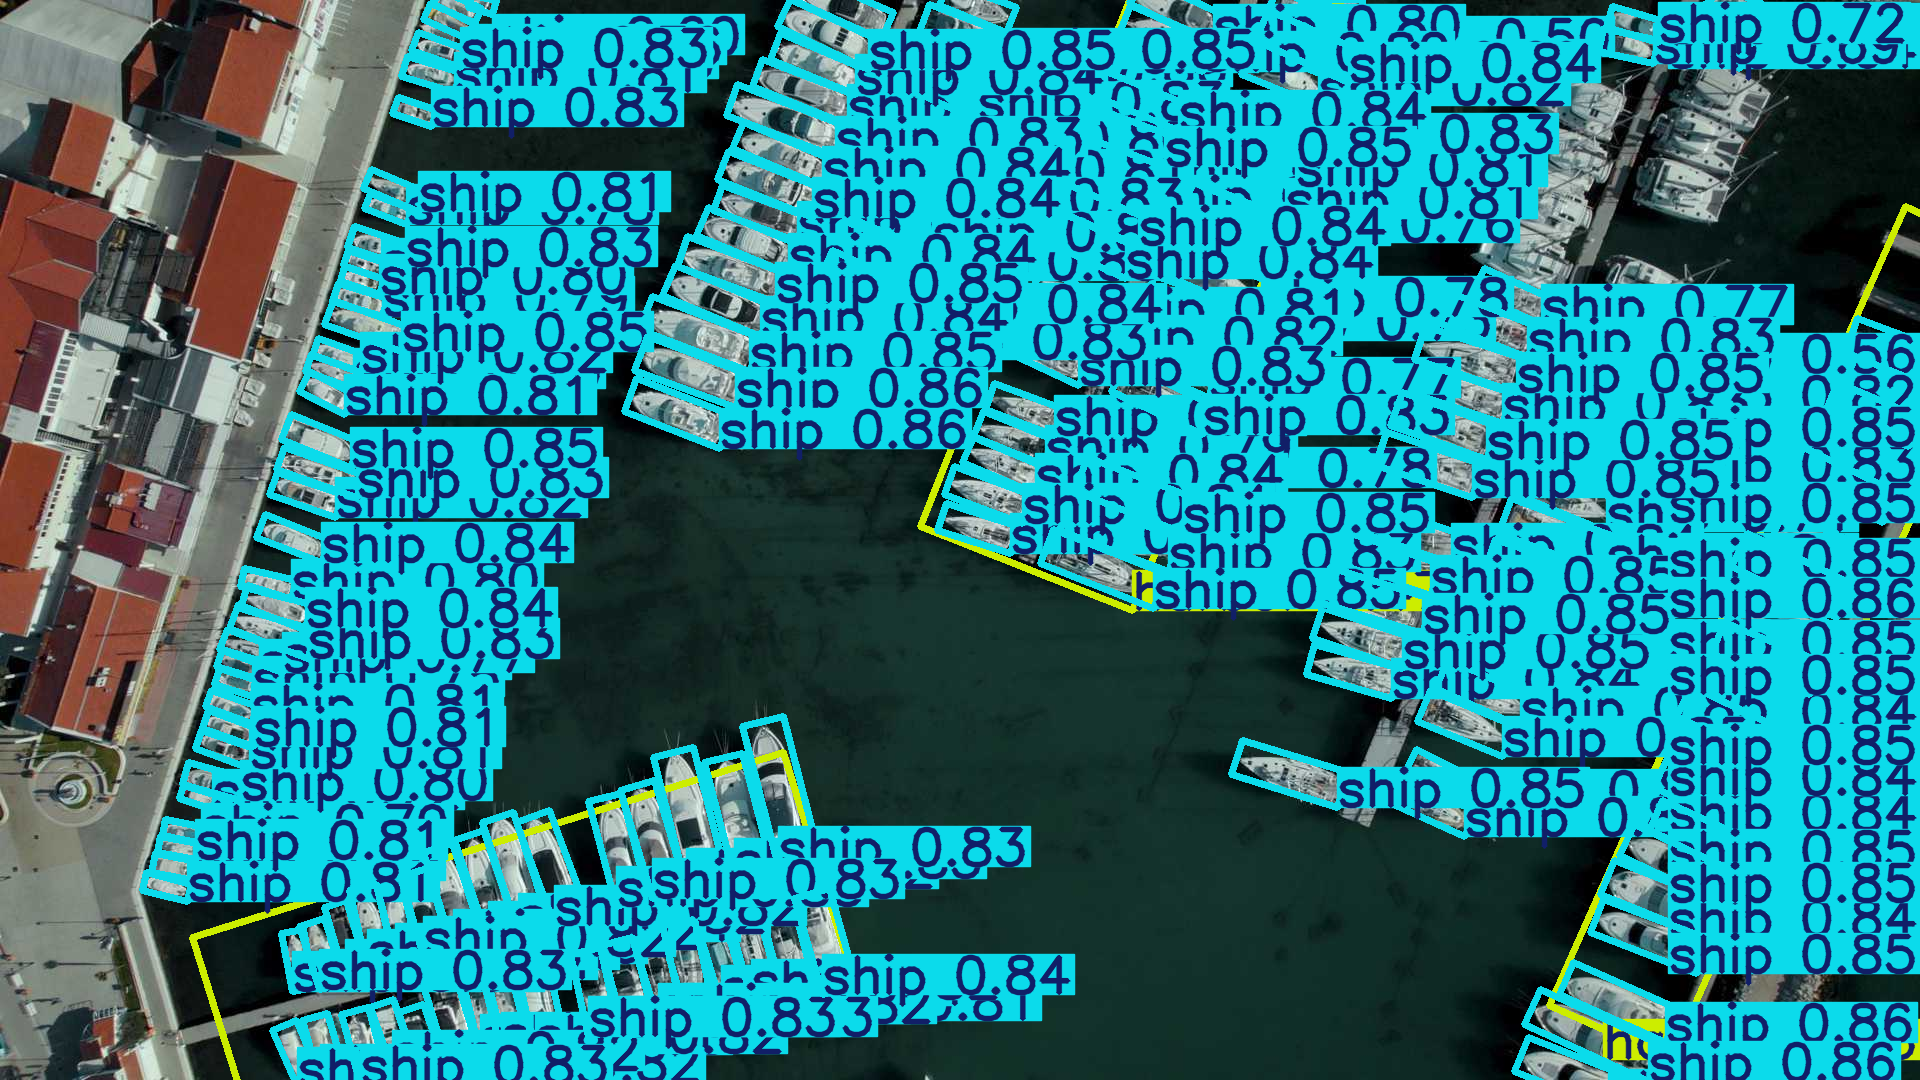

In [3]:
import requests, io, PIL.Image
img = PIL.Image.open(io.BytesIO(
    requests.get('https://ultralytics.com/images/boats.jpg', timeout=30).content
)).convert('RGB')
print(img)
r = model.predict(img, imgsz=1024, conf=0.25, iou=0.5)[0]
print('objects:', 0 if r.obb is None else len(r.obb))
PIL.Image.fromarray(r.plot()[..., ::-1])

## 2. Test trên ảnh của Horus Maps


image 1/1 /mnt/d/Dev/Main/VDT/horus-maps-app/ml/image.png: 1024x1024 5 small vehicles, 6035.8ms
Speed: 48.8ms preprocess, 6035.8ms inference, 42.5ms postprocess per image at shape (1, 3, 1024, 1024)
small vehicle 0.73
small vehicle 0.64
small vehicle 0.57
small vehicle 0.51
small vehicle 0.44


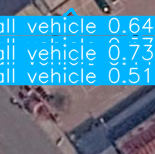

In [4]:
res = model.predict('image.png', imgsz=1024, conf=0.25, classes=VEHICLES)[0]
if res.obb is not None:
    for c, cf in zip(res.obb.cls.tolist(), res.obb.conf.tolist()):
        print(model.names[int(c)], round(cf, 2))
PIL.Image.fromarray(res.plot()[..., ::-1])


## 3. Ảnh lớn -> Chip (Tiling) để không sót vật nhỏ
- Sau khi đưa ảnh lớn vào model -> Resize về 1024 -> Dẫn đến xe nhỏ biến mất.
Ta cần cắt ô 1024 có overlap, predict từng ô, dời box về tọa độ ảnh gốc

In [5]:
import numpy as np

def detect_tiled(model, img, tile=1024, overlap=128, conf=0.25, classes=None):
    """Trả list (poly(4,2) pixel toàn cục, class_id, conf)."""
    W, H = img.size
    step = tile - overlap
    dets = []
    for top in range(0, max(1, H - overlap), step):
        for left in range(0, max(1, W - overlap), step):
            crop = img.crop((left, top, min(left + tile, W), min(top + tile, H)))
            r = model.predict(crop, imgsz=tile, conf=conf, classes=classes, verbose=False)[0]
            if r.obb is None:
                continue
            for poly, c, cf in zip(r.obb.xyxyxyxy.cpu().numpy(),
                                   r.obb.cls.cpu().numpy().astype(int),
                                   r.obb.conf.cpu().numpy()):
                dets.append((poly + np.array([left, top]), int(c), float(cf)))
    return dets

## 4. Trên 1 area of interest (AOI) → GeoJSON

Tải tile vệ tinh hi-res (Esri) phủ bbox → chip → đổi pixel sang lat/lng.
(Google tile cần API key + ToS → dùng Esri để thử.)

In [6]:
import math, requests, io, json, PIL.Image

# Kích thước 1 map tile chuẩn: 256x256 px
TILE = 256

# URL tile ảnh vệ tinh Esri: z=zoom, x/y=chỉ số tile
TILE_URL = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'

# User-Agent để request không bị coi là bot lạ
HEADERS = {'User-Agent': 'horus-maps-demo/1.0'}


def deg2tile(lat, lon, z):
    """Đổi tọa độ lat/lon sang chỉ số tile x/y ở zoom z."""
    n = 2 ** z
    return (
        int((lon + 180) / 360 * n),
        int((1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n)
    )


def pixel_to_lonlat(px, py, z):
    """Đổi pixel toàn cục trên bản đồ sang tọa độ lon/lat."""
    n = 2 ** z
    return (
        px / (TILE * n) * 360 - 180,
        math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * py / (TILE * n)))))
    )


def fetch_mosaic(bbox, z=18):
    """
    Tải các tile vệ tinh phủ bbox rồi ghép thành 1 ảnh lớn.
    bbox = (min_lon, min_lat, max_lon, max_lat)
    """
    # Tile góc trên-trái và dưới-phải của bbox
    x0, y0 = deg2tile(bbox[3], bbox[0], z)
    x1, y1 = deg2tile(bbox[1], bbox[2], z)

    # Số cột/hàng tile cần tải
    cols, rows = x1 - x0 + 1, y1 - y0 + 1

    # Ảnh rỗng để ghép mosaic
    m = PIL.Image.new('RGB', (cols * TILE, rows * TILE))

    # Tải từng tile và dán vào đúng vị trí
    for i, xt in enumerate(range(x0, x1 + 1)):
        for j, yt in enumerate(range(y0, y1 + 1)):
            rr = requests.get(
                TILE_URL.format(z=z, x=xt, y=yt),
                headers=HEADERS,
                timeout=30
            )
            rr.raise_for_status()

            tile_img = PIL.Image.open(io.BytesIO(rr.content)).convert('RGB')
            m.paste(tile_img, (i * TILE, j * TILE))

    # Trả ảnh mosaic và tile gốc để quy đổi tọa độ sau này
    return m, x0, y0, z


def to_geojson(dets, x0, y0, z, names):
    """Đổi kết quả detect từ pixel sang GeoJSON lon/lat."""
    feats = []

    # Offset pixel toàn cục của mosaic
    ox, oy = x0 * TILE, y0 * TILE

    for poly, c, cf in dets:
        # Đổi 4 điểm polygon từ pixel mosaic sang lon/lat
        ring = [
            list(pixel_to_lonlat(ox + px, oy + py, z))
            for px, py in poly
        ]

        # GeoJSON polygon cần đóng vòng: điểm cuối = điểm đầu
        ring.append(ring[0])

        # Tạo 1 feature cho object detect được
        feats.append({
            'type': 'Feature',
            'geometry': {
                'type': 'Polygon',
                'coordinates': [ring]
            },
            'properties': {
                'object_type': names[c],
                'confidence': cf
            }
        })

    return {
        'type': 'FeatureCollection',
        'features': feats
    }

### Test

In [ ]:
import PIL.ImageDraw

# ===== Helper: chạy 1 AOI -> in số lượng theo loại + vẽ box + lưu geojson =====
def run_aoi(name, bbox, z, classes, tile=1024, overlap=128, conf=0.20, out=None):
    mosaic, x0, y0, Z = fetch_mosaic(bbox, z=z)
    print(f"[{name}] mosaic size: {mosaic.size}  (z={Z})")

    dets = detect_tiled(model, mosaic, tile=tile, overlap=overlap, conf=conf, classes=classes)
    print(f"[{name}] {len(dets)} detections")
    # đếm theo loại
    cnt = {}
    for _, c, _ in dets:
        cnt[model.names[c]] = cnt.get(model.names[c], 0) + 1
    print(f"[{name}] by class:", cnt)

    gj = to_geojson(dets, x0, y0, Z, model.names)
    open(out or f"detections_{name}.geojson", "w").write(json.dumps(gj))

    # vẽ box lên ảnh để xem
    vis = mosaic.copy(); d = PIL.ImageDraw.Draw(vis)
    for poly, c, cf in dets:
        col = (0, 255, 0) if c in (0, 11) else (255, 0, 255)   # máy bay=xanh, xe=hồng
        d.polygon([tuple(p) for p in poly], outline=col, width=3)
    return vis

PLANES   = [0, 11]      # plane, helicopter
VEHICLES = [9, 10]      # large-vehicle, small-vehicle

# ----- AOI 1: SÂN BAY NỘI BÀI (nhiều MÁY BAY đậu ở apron) -----
# máy bay to -> z=18 đủ nét và chắc có ảnh. Đổi bbox nếu lệch apron.
vis_plane = run_aoi("noibai_planes",
                    bbox=(105.798, 21.213, 105.812, 21.223),
                    z=18, classes=PLANES, conf=0.20,
                    out="detections.geojson")
display(vis_plane)

[noibai_planes] mosaic size: (2816, 2304)  (z=18)


## 5. Export ONNX cho worker
